# Classification Models, Evaluation Metrics & Handling Imbalanced Data

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

## Load Dataset

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())

print()

print("Target Names:", data.target_names)

print("Shape:", X.shape)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

## Class Distribution

In [4]:
print(pd.Series(y).value_counts())

1    357
0    212
Name: count, dtype: int64


## Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Scaling

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Train Logistic Regression

In [7]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## Prediction

In [8]:
y_pred = model.predict(X_test_scaled)

## Accuracy

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 0.9824561403508771
Accuracy: 98.25%


## Confusion Matrix

In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[41  1]
 [ 1 71]]


## Plot Confusion Matrix

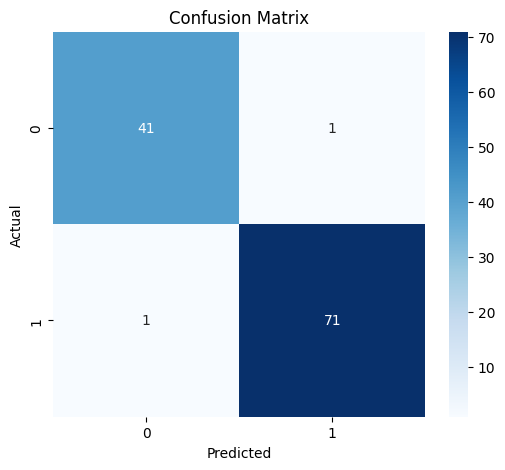

In [12]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

## Classification Report

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## ROC Curve

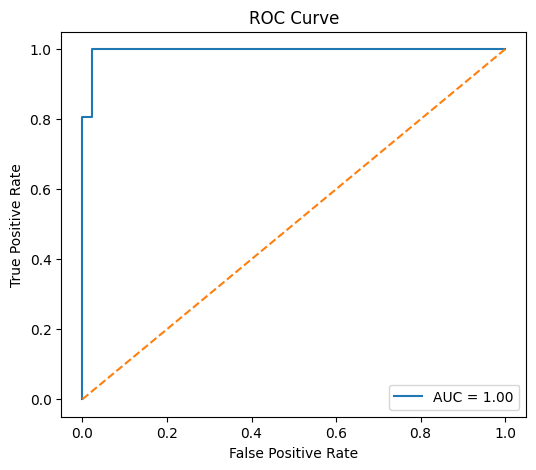

AUC Score: 0.9953703703703703


In [14]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("roc_curve.png")

plt.show()

print("AUC Score:", auc)

## Handle Imbalanced Data

In [15]:
balanced_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

balanced_model.fit(X_train_scaled, y_train)

balanced_pred = balanced_model.predict(X_test_scaled)

print(classification_report(y_test, balanced_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



## Decision Tree Classifier

In [16]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



## Compare Models

In [17]:
lr_accuracy = accuracy_score(y_test, y_pred)
tree_accuracy = accuracy_score(y_test, tree_pred)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [lr_accuracy, tree_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.982456
1,Decision Tree,0.912281


## Explanations

### What is Classification?
Classification predicts categorical labels such as Yes/No, Spam/Not Spam, or Benign/Malignant.

### What is a Confusion Matrix?
A confusion matrix summarizes model predictions into:
True Positives
True Negatives
False Positives
False Negatives

### Why is Accuracy Not Enough?
Accuracy can be misleading on imbalanced datasets because predicting only the majority class can still give high accuracy while missing important cases.

### Precision
Precision measures how many predicted positive cases are actually positive.

### Recall
Recall measures how many actual positive cases are correctly identified.

### F1 Score
F1 Score is the harmonic mean of Precision and Recall and is useful for imbalanced datasets.

### ROC Curve
The ROC Curve shows the trade-off between the True Positive Rate and False Positive Rate across different thresholds.

### AUC Score
AUC measures the classifier's ability to distinguish between classes. Values closer to 1 indicate better performance.

### Class Imbalance
Class imbalance occurs when one class has significantly more samples than the other. Using class_weight="balanced" helps reduce bias toward the majority class.

### Accuracy Analysis
The Logistic Regression model achieved an accuracy of 98.25%, indicating that it correctly predicted the class labels for most of the test samples.
A high accuracy suggests that the model performs well on this dataset. However, relying only on accuracy can sometimes give a misleading impression, especially when the classes are not evenly distributed. To obtain a complete evaluation of the model, additional metrics such as the Confusion Matrix, Precision, Recall, F1-Score, and ROC-AUC Score should also be considered.

